# 6. Exercises
### Exercise 1
Create a categorical distribution with 4 categories of your choice and assign probabilities.  
- Sample 20 outcomes.  
- Print the frequency of each category.  

In [2]:
import numpy as np


categories = ["A", "B", "C", "D"] # 4 named categories
probs = [0.1, 0.4, 0.3, 0.2]  # must sum to 1
n_trials = 20 # must be 20 trials
samples = np.random.choice(categories, size=n_trials, p=probs)
for c in categories:
    count = np.sum(samples == c)
    print(f"Frequency of {c}: {count/20:.2f}") # frequency format doesnt matter as long as the code is correct

Frequency of A: 0.20
Frequency of B: 0.30
Frequency of C: 0.20
Frequency of D: 0.30


### Exercise 2
Using your sampled outcomes from Exercise 1, perform One-Hot Encoding.  
- Show the first 5 encoded vectors.  

In [16]:
from sklearn.preprocessing import OneHotEncoder
X = np.array(samples).reshape(-1, 1)

encoder = OneHotEncoder(sparse_output=False, categories="auto")
X_encoded = encoder.fit_transform(X)

print(X_encoded[:5])


[[0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]]


### Exercise 3
Run 100 experiments of 10 trials each using the multinomial distribution.  
- Record the counts.  
- Compare the average counts to the theoretical probabilities.  

In [3]:
# Run 100 experiments of 10 trials each
n_experiments = 100
n_per_experiment = 10

multi_samples = np.random.multinomial(n_per_experiment, probs, size=n_experiments)

# Average counts across experiments
avg_counts = multi_samples.mean(axis=0) / n_per_experiment # format here doesnt matter
print(avg_counts)

#OR if they use manually loops

# Storage for total counts across experiments
totals = [0,0,0,0]

# Run experiments manually
for exp in range(n_experiments):
    samples = np.random.choice(categories, size=n_per_experiment, p=probs)
    for i, c in enumerate(categories):
        count = np.sum(samples == c)
        totals[i] += count
normalized_totals = []
for item in totals:
    normalized_totals.append(item/(n_per_experiment*n_experiments))
print(normalized_totals)




[0.098 0.397 0.301 0.204]
[np.float64(0.1), np.float64(0.392), np.float64(0.308), np.float64(0.2)]


### Exercise 4
Plot a histogram showing the distribution of counts for one category (e.g., "B") across multiple multinomial experiments.  
- What shape does the histogram resemble?  
- Why do you think that is?  

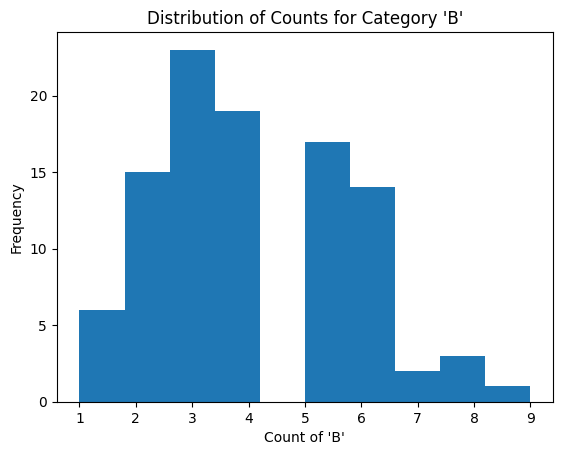

In [5]:
import matplotlib.pyplot as plt

# Take counts for category "B" (index 1)
counts_B = multi_samples[:, 1]

plt.hist(counts_B, bins=10)
plt.title("Distribution of Counts for Category 'B'")
plt.xlabel("Count of 'B'")
plt.ylabel("Frequency")
plt.show()


### Exercise 5
Answer in text (2–3 sentences each):

1. How does the categorical distribution differ from the multinomial distribution?  
2. Why is One-Hot encoding important for machine learning models?  
3. If you increased the number of trials in the multinomial distribution, what would happen to the observed frequencies? Why?


1. The categorical distribution models the outcome of a single trial with multiple possible categories.
The multinomial distribution generalizes this to multiple independent trials, counting how many times each category occurs.
2. One-Hot encoding converts categorical labels into a numerical form without introducing unintended order or magnitude.
This prevents algorithms from incorrectly assuming relationships between categories, while still allowing the model to process them as input features.
3. As the number of trials increases, the relative frequencies of categories converge closer to their theoretical probabilities.
This is due to the Law of Large Numbers, which states that with more samples, the observed proportions stabilize around the true distribution.